<a href="https://colab.research.google.com/drive/1tAgbjrtiVSNS4MmNjzobwZF5Vd1EWMwy?usp=sharing" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import kagglehub

# Download latest version
path = kagglehub.dataset_download("usdot/flight-delays")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'flight-delays' dataset.
Path to dataset files: /kaggle/input/flight-delays


# Homework


The homework is to prepare a report for the Ministry of Transport, revealing the nature and characteristics of flight delays. The report should help identify problem areas and contribute to decision-making. Therefore, strive not to state general facts, but to show problems. For example, the fact "the average departure delay is 15 minutes" by itself says little and does not help to understand why this is happening. On the contrary, a graph showing that on Mondays delays increase threefold compared to other days against the background of an increase in the number of flights and passengers suggests a possible cause of the problem: airports cannot cope with uneven load.

The report should be in the form of a notebook with a clear structure. At the beginning of the Markdown cell there is a brief description of the question under study (what we will study), then the code and all its outputs (tables, graphs, values), then again in the Markdown cell in which your brief conclusion is formulated.

The report should contain at least **5 results** confirmed by graphs. For variety of material, use different types of diagrams. All graphs should be provided with the necessary signatures (axis designations, title, color scheme legend).

To solve the problems, use the methods of the `pandas` library.

In [3]:
#ЗАГРУЖАЕМ ДАННЫЕ В ПЕРЕМЕННЫЕ
import os

flights = pd.read_csv(os.path.join(path, "flights.csv"))
airlines = pd.read_csv(os.path.join(path, "airlines.csv"))
airports = pd.read_csv(os.path.join(path, "airports.csv"))

/tmp/ipykernel_2842/3310039842.py:4: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  flights = pd.read_csv(os.path.join(path, "flights.csv"))


###1. Задержки и отмены по вине авикомпании
Исследуем задержки/отмены по вине авиакомпании: лидеров по этому количеству, среднее значение опозданий в минутах

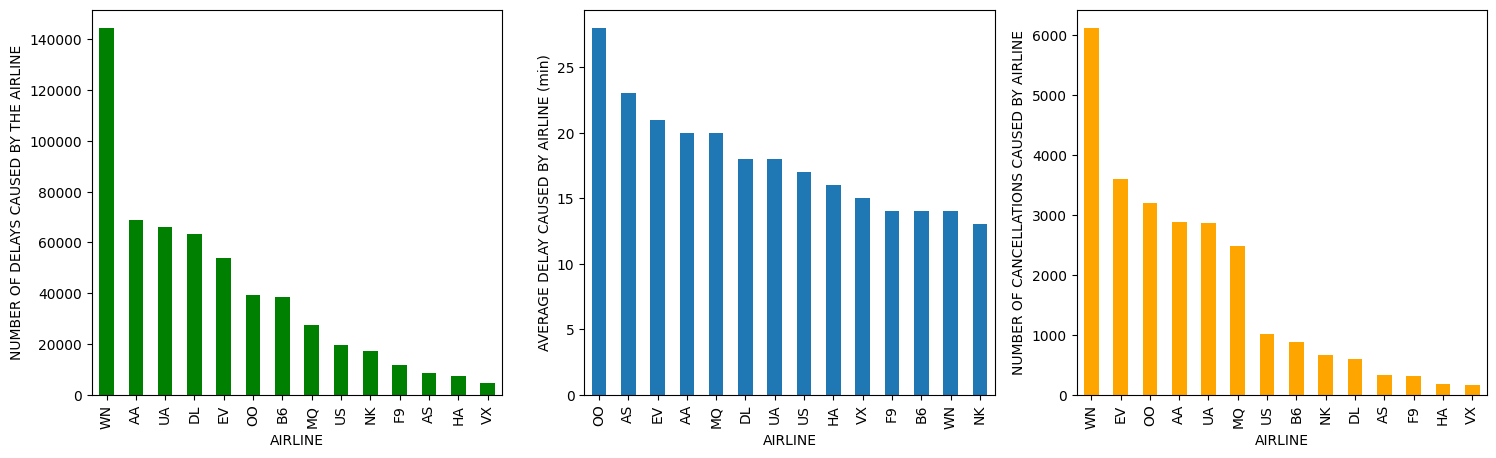

,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways
5,OO,Skywest Airlines Inc.
6,AS,Alaska Airlines Inc.
7,NK,Spirit Air Lines
8,WN,Southwest Airlines Co.
9,DL,Delta Air Lines Inc.


In [4]:
airline_del = flights[["AIRLINE", "AIRLINE_DELAY"]].dropna()
airline_del = airline_del[airline_del['AIRLINE_DELAY'] != 0]




fig, ax = plt.subplots(1, 3, figsize=(18, 5))

airline_del['AIRLINE'].value_counts().plot(kind = "bar", ax = ax[0], color = "green")
ax[0].set_ylabel("NUMBER OF DELAYS CAUSED BY THE AIRLINE")
overall_mean = airline_del["AIRLINE_DELAY"].mean()


airline_delay_median = (
    airline_del
    .groupby("AIRLINE")["AIRLINE_DELAY"]
    .median()
    .sort_values(ascending=False)
)
airline_delay_median.plot(kind = "bar", ax = ax[1])
ax[1].set_ylabel("AVERAGE DELAY CAUSED BY AIRLINE (min)")


airline_cancel = flights[["AIRLINE", "CANCELLED", "CANCELLATION_REASON"]].dropna()
airline_cancel = airline_cancel[airline_cancel['CANCELLATION_REASON'] == "A"]
airline_cancel_stat = (
    airline_cancel
    .groupby("AIRLINE")["CANCELLED"]
    .sum()
    .sort_values(ascending=False)
)
airline_cancel_stat.plot(kind = "bar", color = "orange", ax = ax[2])
ax[2].set_ylabel("NUMBER OF CANCELLATIONS CAUSED BY AIRLINE")

plt.show()
df_air = pd.read_csv(os.path.join(path, 'airlines.csv'))
df_air



Как можем заметить, самой ненадежжной команией является "Southwest Airlines Co." с наибольшим числом задержек (примерно каждый четвертый) и отмен рейсов по их вине.

###2. Погодные задержки
 Рассмотрим погодный фактор (задержки и отмены) а также аэропорты наиболее подверженные этому фактору.

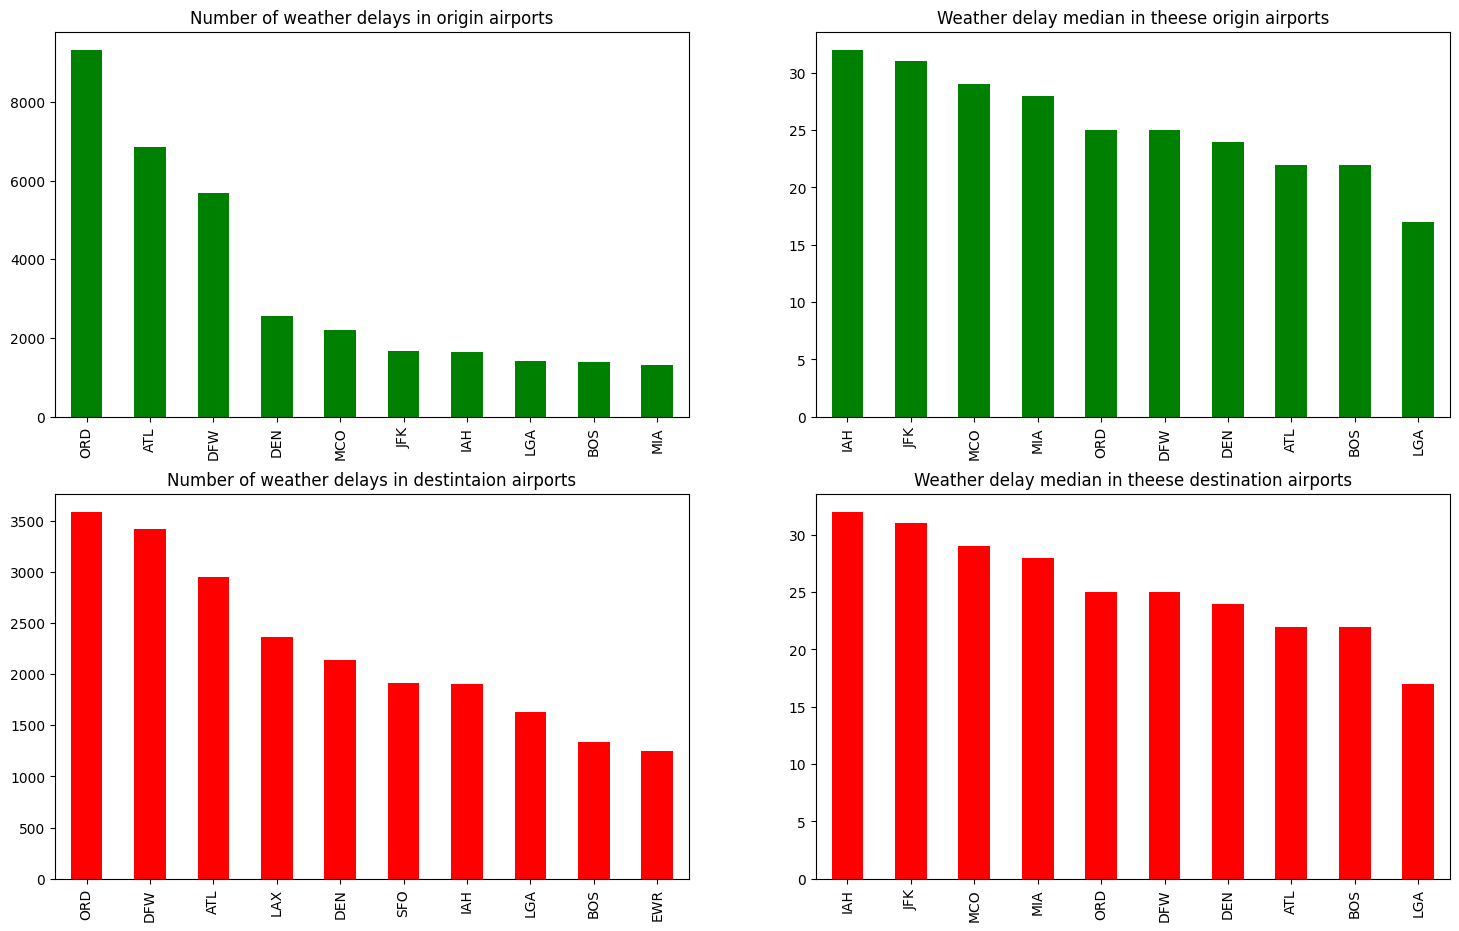

Origin airports                                                     \
        IATA_CODE                                            AIRPORT   
0             ATL   Hartsfield-Jackson Atlanta International Airport   
1             BOS   Gen. Edward Lawrence Logan International Airport   
2             DEN                       Denver International Airport   
3             DFW            Dallas/Fort Worth International Airport   
4             IAH               George Bush Intercontinental Airport   
5             JFK  John F. Kennedy International Airport (New Yor...   
6             LGA            LaGuardia Airport (Marine Air Terminal)   
7             MCO                      Orlando International Airport   
8             MIA                        Miami International Airport   
9             ORD               Chicago O'Hare International Airport   

                           Destination airports  \
                CITY STATE            IATA_CODE   
0            Atlanta    GA                  ATL   
1             Boston    MA                  BOS   
2             Denver    CO                  DEN   
3  Dallas-Fort Worth    TX                  DFW   
4            Houston    TX                  EWR   
5           New York    NY                  IAH   
6           New York    NY                  LAX   
7            Orlando    FL                  LGA   
8              Miami    FL                  ORD   
9            Chicago    IL                  SFO   

                                                                              
                                            AIRPORT               CITY STATE  
0  Hartsfield-Jackson Atlanta International Airport            Atlanta    GA  
1  Gen. Edward Lawrence Logan International Airport             Boston    MA  
2                      Denver International Airport             Denver    CO  
3           Dallas/Fort Worth International Airport  Dallas-Fort Worth    TX  
4              Newark Liberty International Airport             Newark    NJ  
5              George Bush Intercontinental Airport            Houston    TX  
6                 Los Angeles International Airport        Los Angeles    CA  
7           LaGuardia Airport (Marine Air Terminal)           New York    NY  
8              Chicago O'Hare International Airport            Chicago    IL  
9               San Francisco International Airport      San Francisco    CA

In [ ]:
from re import A

weather_del = flights[["ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "WEATHER_DELAY"]].dropna()
weather_del = weather_del[weather_del['WEATHER_DELAY'] != 0]

fig, ax = plt.subplots(2, 2, figsize=(18, 11))

orig_del = weather_del['ORIGIN_AIRPORT'].value_counts().head(10)
weather_del['ORIGIN_AIRPORT'].value_counts().head(10).plot(kind = "bar", ax = ax[0, 0], color = "green")
ax[0, 0].set_title("Number of weather delays in origin airports")
ax[0, 0].set_xlabel("")

dest_del = weather_del['DESTINATION_AIRPORT'].value_counts().head(10)
weather_del['DESTINATION_AIRPORT'].value_counts().head(10).plot(kind = "bar",ax = ax[1, 0], color = "red")
ax[1, 0].set_title("Number of weather delays in destintaion airports")
ax[1, 0].set_xlabel("")

orig_airports = {'ORD', 'ATL', 'DFW', 'DEN', 'MCO', 'JFK', 'IAH', 'LGA', 'BOS', 'MIA'}

orig_del_median = (
    weather_del[weather_del['ORIGIN_AIRPORT'].isin(orig_airports)]
    .groupby("ORIGIN_AIRPORT")["WEATHER_DELAY"]
    .median()
    .sort_values(ascending=False)
)
orig_del_median.plot(kind = "bar",ax = ax[0, 1], color = "green")
ax[0, 1].set_title("Weather delay median in theese origin airports")
ax[0, 1].set_xlabel("")

dest_airports = {'ORD', 'DFW', 'ATL', 'LAX', 'DEN', 'SFO', 'IAH', 'LGA', 'BOS', 'EWR'}

dest_del_median = (
  weather_del[weather_del['DESTINATION_AIRPORT'].isin(dest_airports)]
  .groupby("DESTINATION_AIRPORT")["WEATHER_DELAY"]
  .median()
  .sort_values(ascending=False)
)
orig_del_median.plot(kind = "bar",ax = ax[1, 1], color = "red")
ax[1, 1].set_title("Weather delay median in theese destination airports")
ax[1, 1].set_xlabel("")

plt.show()

airport_to_name = dict(zip(airports['IATA_CODE'], airports['AIRPORT']))

orig_airports_from_list = airports[
    airports['IATA_CODE'].isin(orig_airports)
][['IATA_CODE', 'AIRPORT', 'CITY', 'STATE']]



dest_airports_from_list = airports[
    airports['IATA_CODE'].isin(dest_airports)
][['IATA_CODE', 'AIRPORT', 'CITY', 'STATE']]

pd.concat(
    [
        orig_airports_from_list.reset_index(drop=True),
        dest_airports_from_list.reset_index(drop=True)
    ],
    axis=1,
    keys=["Origin airports", "Destination airports"]
)


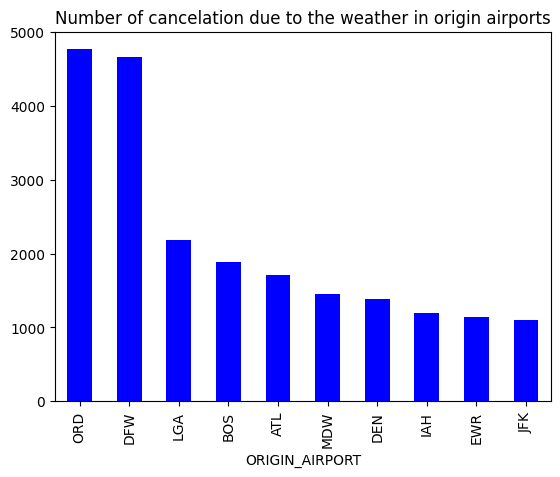

In [ ]:
weather_airport_cancel = flights[["ORIGIN_AIRPORT", "CANCELLED", "CANCELLATION_REASON"]].dropna()
weather_airport_cancel = weather_airport_cancel[weather_airport_cancel['CANCELLATION_REASON'] == "B"]
weather_cancel_stat = (
    weather_airport_cancel
    .groupby("ORIGIN_AIRPORT")["CANCELLED"]
    .sum()
    .sort_values(ascending=False)
)
weather_cancel_stat.head(10).plot(kind = "bar", color = "blue")
plt.title("Number of cancelation due to the weather in origin airports")
plt.show()

я только в конце понял что это бесполезные данные тк эти аэропорты самые нагруженные и оттуда летают в какие то деревни с плохой погодой поэтому так много отмен но я потратил столько времени что жалко удалять, простите

### 3. Зависимость задержек от дня недели

Проверим, в какие дни недели рейсы чаще задерживаются и где медианная задержка выше.  
Это важно, потому что если задержки чаще наблюдаются в определённые дни, проблема может быть связана с недельной нагрузкой аэропортов и авиакомпаний.

,День недели,"Медианная задержка прилёта, минут",Количество задержанных рейсов
0,Понедельник,16.0,314978
1,Вторник,15.0,295171
2,Среда,15.0,304289
3,Четверг,15.0,335560
4,Пятница,15.0,326419
5,Суббота,14.0,224677
6,Воскресенье,15.0,285802


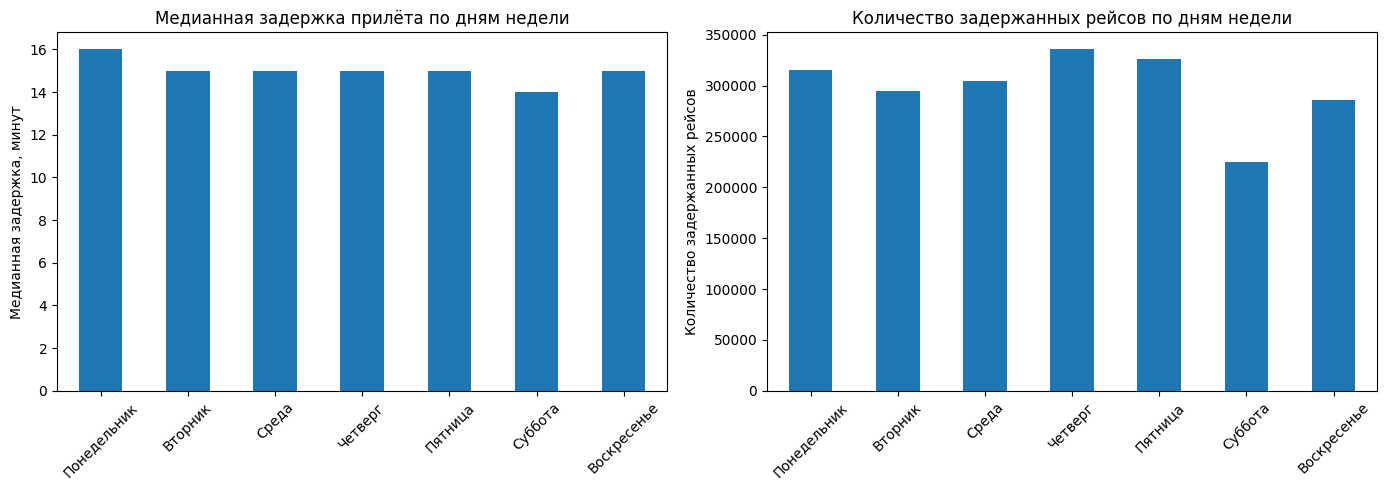

In [6]:
day_delay = flights[['DAY_OF_WEEK', 'ARRIVAL_DELAY']].dropna()
day_delay = day_delay[day_delay['ARRIVAL_DELAY'] > 0]

day_names = {
    1: 'Понедельник',
    2: 'Вторник',
    3: 'Среда',
    4: 'Четверг',
    5: 'Пятница',
    6: 'Суббота',
    7: 'Воскресенье'
}

day_median = (
    day_delay
    .groupby('DAY_OF_WEEK')['ARRIVAL_DELAY']
    .median()
)

day_count = (
    day_delay
    .groupby('DAY_OF_WEEK')['ARRIVAL_DELAY']
    .count()
)

day_table = pd.DataFrame({
    'День недели': day_median.index.map(day_names),
    'Медианная задержка прилёта, минут': day_median.values,
    'Количество задержанных рейсов': day_count.values
})

display(day_table)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

day_median.index = day_median.index.map(day_names)
day_count.index = day_count.index.map(day_names)

day_median.plot(kind='bar', ax=ax[0])
ax[0].set_title('Медианная задержка прилёта по дням недели')
ax[0].set_xlabel('')
ax[0].set_ylabel('Медианная задержка, минут')
ax[0].tick_params(axis='x', rotation=45)

day_count.plot(kind='bar', ax=ax[1])
ax[1].set_title('Количество задержанных рейсов по дням недели')
ax[1].set_xlabel('')
ax[1].set_ylabel('Количество задержанных рейсов')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

По графикам видно, что задержки распределены по дням недели неравномерно.  
В некоторые дни наблюдается больше задержанных рейсов, а также может быть выше медианная задержка.


### 4. Сезонная зависимость задержек

Проверим, как задержки рейсов меняются по месяцам.



,Месяц,"Медианная задержка прилёта, минут",Количество задержанных рейсов
0,Январь,16.0,183110
1,Февраль,17.0,175443
2,Март,15.0,190133
3,Апрель,14.0,171820
4,Май,15.0,175178
5,Июнь,18.0,206989
6,Июль,17.0,199717
7,Август,16.0,180891
8,Сентябрь,12.0,133432
9,Октябрь,11.0,141250


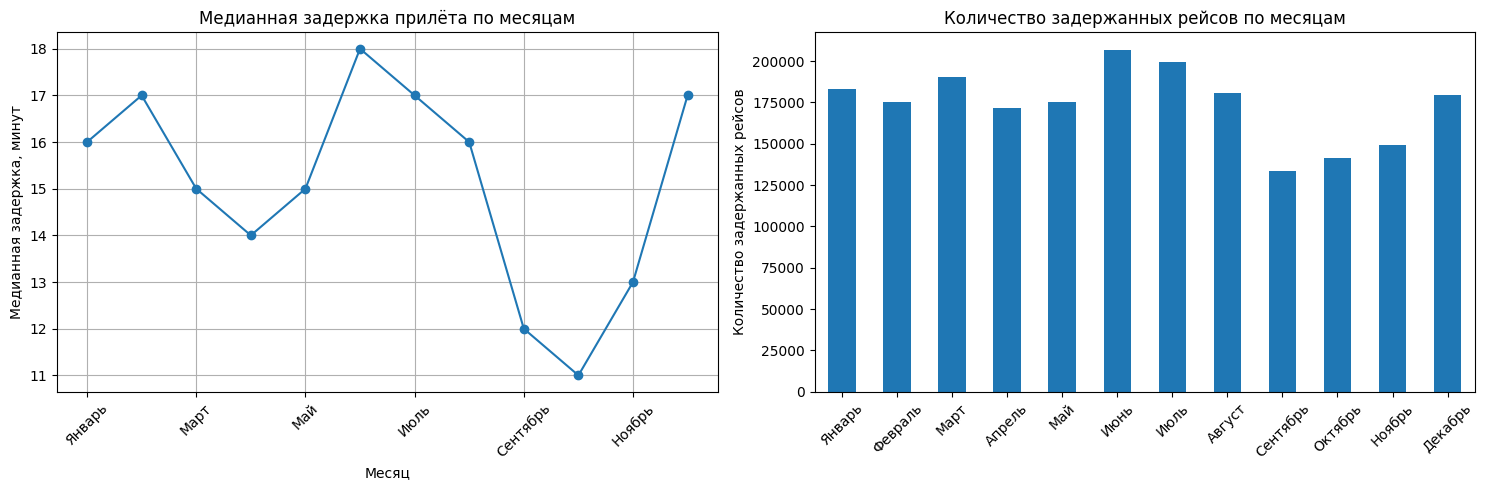

In [7]:
month_delay = flights[['MONTH', 'ARRIVAL_DELAY']].dropna()
month_delay = month_delay[month_delay['ARRIVAL_DELAY'] > 0]

month_names = {
    1: 'Январь',
    2: 'Февраль',
    3: 'Март',
    4: 'Апрель',
    5: 'Май',
    6: 'Июнь',
    7: 'Июль',
    8: 'Август',
    9: 'Сентябрь',
    10: 'Октябрь',
    11: 'Ноябрь',
    12: 'Декабрь'
}

month_median = (
    month_delay
    .groupby('MONTH')['ARRIVAL_DELAY']
    .median()
)

month_count = (
    month_delay
    .groupby('MONTH')['ARRIVAL_DELAY']
    .count()
)

month_table = pd.DataFrame({
    'Месяц': month_median.index.map(month_names),
    'Медианная задержка прилёта, минут': month_median.values,
    'Количество задержанных рейсов': month_count.values
})

display(month_table)

month_median.index = month_median.index.map(month_names)
month_count.index = month_count.index.map(month_names)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

month_median.plot(kind='line', marker='o', ax=ax[0])
ax[0].set_title('Медианная задержка прилёта по месяцам')
ax[0].set_xlabel('Месяц')
ax[0].set_ylabel('Медианная задержка, минут')
ax[0].grid(True)
ax[0].tick_params(axis='x', rotation=45)

month_count.plot(kind='bar', ax=ax[1])
ax[1].set_title('Количество задержанных рейсов по месяцам')
ax[1].set_xlabel('')
ax[1].set_ylabel('Количество задержанных рейсов')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

По графикам видно, что задержки зависят от месяца.  
В разные месяцы количество задержанных рейсов и медианная задержка отличаются.
Например, летом в период отпусков.

### 5. Связь расстояния рейса и задержки прилёта

Проверим, связана ли задержка прилёта с расстоянием рейса.


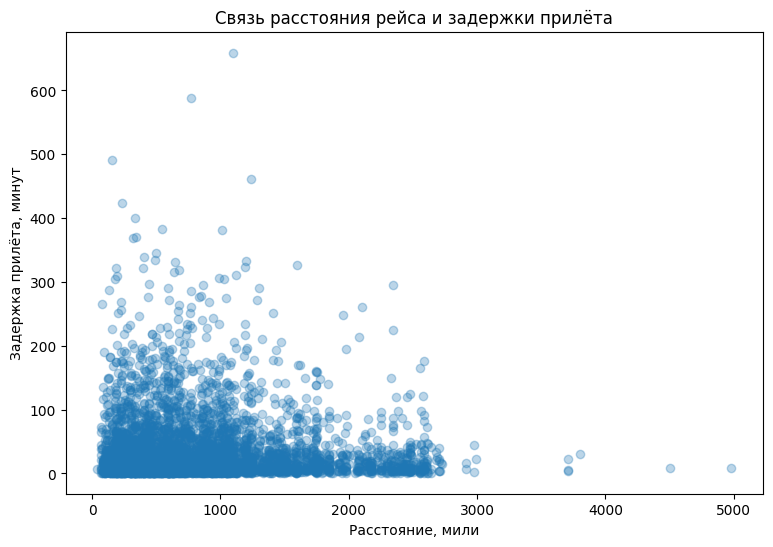

,Показатель,Значение
0,Корреляция между расстоянием и задержкой прилёта,0.00823


In [8]:
distance_delay = flights[['DISTANCE', 'ARRIVAL_DELAY']].dropna()
distance_delay = distance_delay[distance_delay['ARRIVAL_DELAY'] > 0]

distance_sample = distance_delay.sample(
    n=min(5000, len(distance_delay)),
    random_state=42
)

plt.figure(figsize=(9, 6))

plt.scatter(
    distance_sample['DISTANCE'],
    distance_sample['ARRIVAL_DELAY'],
    alpha=0.3
)

plt.title('Связь расстояния рейса и задержки прилёта')
plt.xlabel('Расстояние, мили')
plt.ylabel('Задержка прилёта, минут')

plt.show()

correlation = distance_delay['DISTANCE'].corr(distance_delay['ARRIVAL_DELAY'])

distance_table = pd.DataFrame({
    'Показатель': ['Корреляция между расстоянием и задержкой прилёта'],
    'Значение': [correlation]
})

display(distance_table)

Диаграмма рассеяния показывает, есть ли выраженная связь между расстоянием рейса и задержкой прилёта.

Если точки расположены хаотично, а коэффициент корреляции близок к нулю, то расстояние само по себе не является главным фактором задержек. В таком случае более вероятно, что задержки связаны с другими причинами: загруженностью аэропортов, погодой, работой авиакомпаний или поздним прибытием самолёта с предыдущего рейса.

####МЯУ МЯУ МЯУ